# Test statistics and the likelihood ratio test

You have collected some data with a particle collider experiment at CERN. In particular, you are measuring an angle between 0 and $\pi$ and you expect to have a flat uniform background. 

There are two different signal hypothesis and you are collecting data to take 2 decisions:
1) is the data compatible with the bkg-only hypotheses?
2) if the data is not compatible with the bkg-only hypothesis with a 99% significance level --> then which of the two signal hypothesis is more probable?

The shape of the two signal hypothesis has been simulated with Monte Carlo (MC) and it is given to you in the form of "simulated events". You can find the value of the simulated angles in the files "MC_signal_1" and "MC_signal_2". 

The total number of expected events for background and signal depends on their "cross-section" (XS) (their probability of happening) and by the "luminosity" of your experiment (roughly how many times you make particles collide to perform this experiment). 

You can compute the expected number of events by $ N = \mathcal{L} * XS$.
The XS of the background is 1 pb (picobarn) whereas the expected XS of the signal is 0.1 pb for both the hypothesis. 

The measured data is given to you in "data_lumi_LUMI.0.npy" files, corresponding to the datata collected for increasing luminosities  [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5] #/pb.


## Exercise 1
- Plot the expected sig+bkg distribution and the recorded data for the two signal hypothesis, for different collected luminosity values.  ([1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5] #/pb.)

- Build a binned likelihood for the signal + background model.
  - vary the number of bins: [2, 5, 10, 20, 30] 
  - Plot the likelihood of observing the data for the datasets collected with increasing luminosity (more and more data collected). What do you observe?
  - Plot the likelihood increasing the number of bins

### Exercise 1.2

Consider the 3 hypothesis: background-only, background+sig1, background+sig2

- Build a test statistics for B vs Sig1, B vs Sig2
    - Use the **likelihood ratio** as a test statistics:
        - Plot the test statistic distribution using toys generated with the bkg-only hypothesis or with the two signal hypothesis.
        - Compute the "observed" value of the test statistics on data. What do you observe?
        - Plot the test statistics for increasing luminosity and number of bins. Which trend you can observe?

    - Compute the test statistic power and significance with a varying luminosity. How much are the Type I and Type II errors for the two tests?

## Exercise2: 
Build an hypothesis test to choose one of the signal hypothesis. 
- Quantify the p-value of the incompatibility of data with the sig1 (or sig2) varying the luminosity and number of bins.
- What is the best number of bins to discriminate the two signal hypothesis?

## Exercise 3 (extra): 
Invent a test statistics (e.g. the ratio of the number of events with ($|\theta - \pi/2|>0.5$ and the $|\theta - \pi/2|<0.5$ ) and compare is power with the likelihood ratio at fixed significance of 99%.
/

# Solutions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import speed_of_light
from dataclasses import dataclass
import pandas as pd
from scipy.stats import poisson, norm
from scipy.optimize import minimize, curve_fit
import seaborn as sns
import scipy.special

# fix seed
np.random.seed(42)


In [2]:
# Let's build a binned likelihood 

In [3]:
@dataclass
class BinnedNLL:
    exp_counts_sig: np.ndarray
    exp_counts_bkg: np.ndarray
    data: np.ndarray

    def __call__(self, params):
        mu = params[0] # number of events
        exp_total = self.exp_counts_bkg + mu*self.exp_counts_sig
        log_likelihood  =  self.data*np.log(exp_total) - exp_total # do not include -log(data!) as it would be just a very large constanct factor
        return (log_likelihood).sum(axis=-1)

    def toss_toys(self, Ntoys, params):
        mu = params[0]
        exp_total = self.exp_counts_bkg + mu*self.exp_counts_sig
        # sample Ntoys for each bin
        return np.random.poisson(exp_total, size=(Ntoys, len(exp_total))) 

We need to have the expected number of signal and background events in each bin depending on the luminosity, the cross-section and the Number of bins. 

The shape of the 2 signal hypotheses is given in form of simulated events. The actual weights of these simulated events needs to be rescaled so that the overall number of expected events corresponds to the lumi*XS

In [4]:
bkg_XS = 1 #pb
sig_XS = 0.01 #pb

In [5]:
def get_sig_density(lumi, signal_XS, Nbins, sig_hypothesis ):
    N_event_expected = lumi*signal_XS

    if sig_hypothesis == 1:    
        MC_sig = np.load("MC_signal_1.npy")
    elif sig_hypothesis == 2:  
        MC_sig = np.load("MC_signal_2.npy")
    
    counts_sig, _ = np.histogram(MC_sig, weights=np.ones(len(MC_sig))*N_event_expected/len(MC_sig), bins=Nbins, range=(0, np.pi))
    return counts_sig

def get_bkg_density(lumi, bkg_XS, Nbins):
    N_event_expected = lumi*bkg_XS
    exp_counts_bkg = np.ones(Nbins)* N_event_expected/ Nbins
    return exp_counts_bkg

Let's get the likelihood for lumi=100/pb

In [6]:
lumis = [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6] #/pb

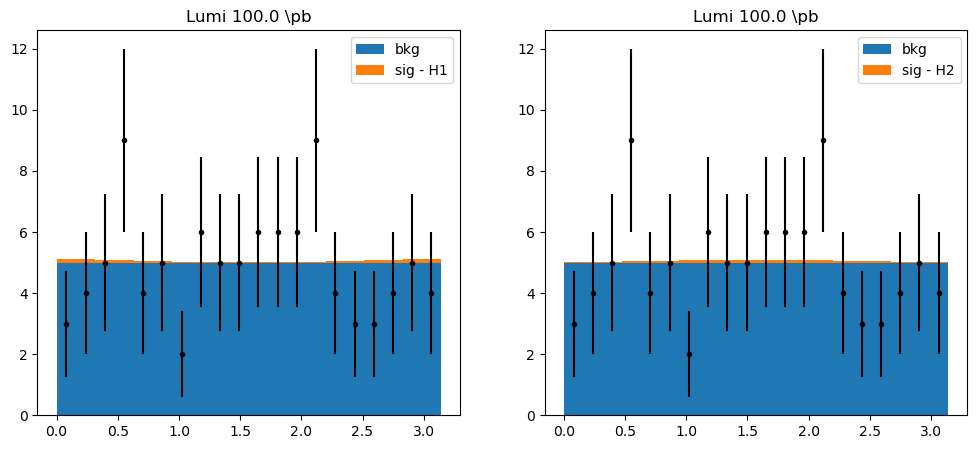

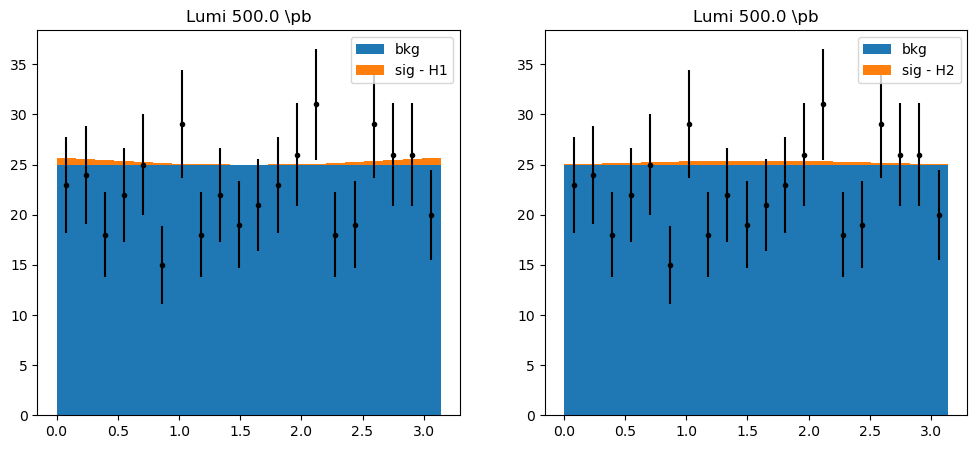

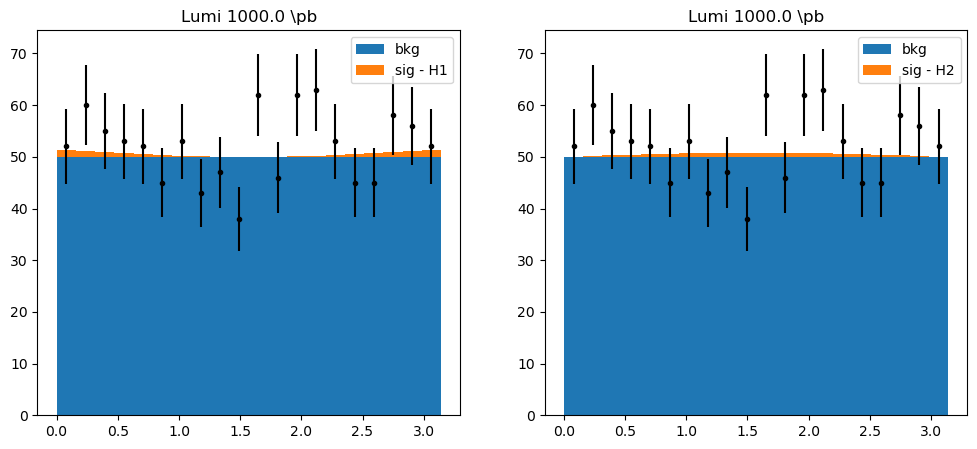

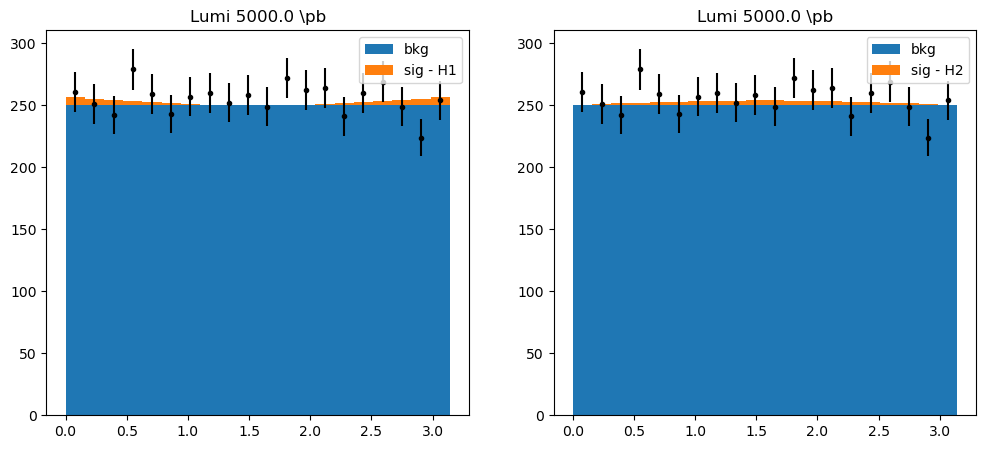

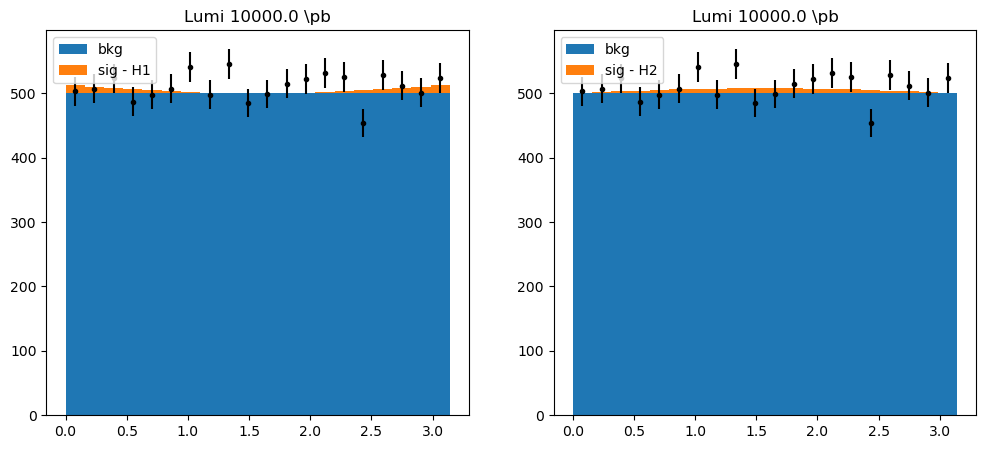

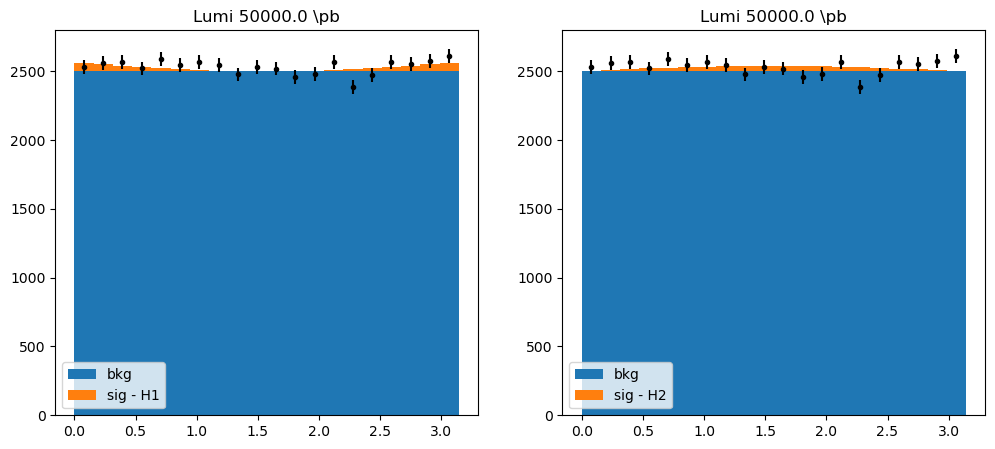

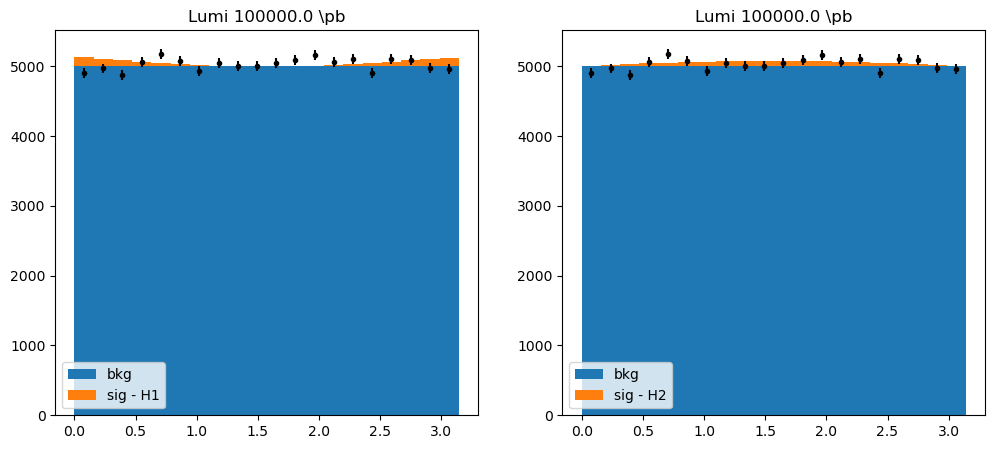

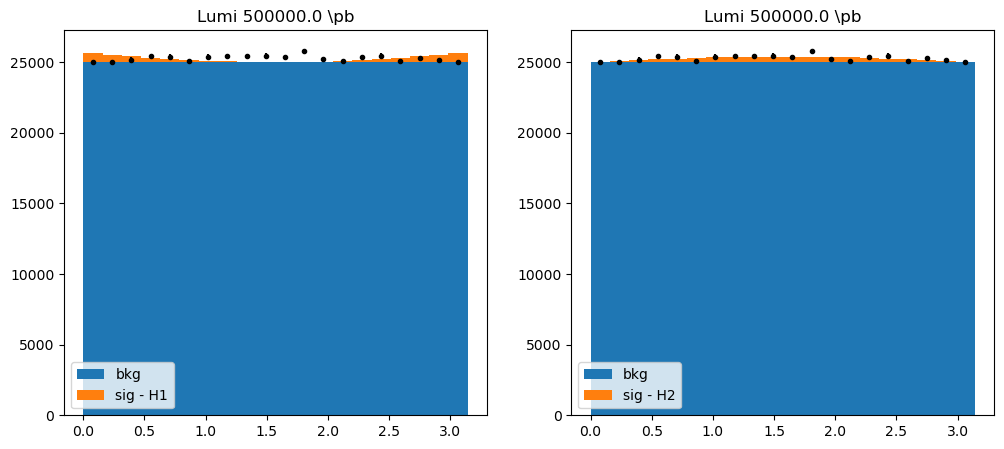

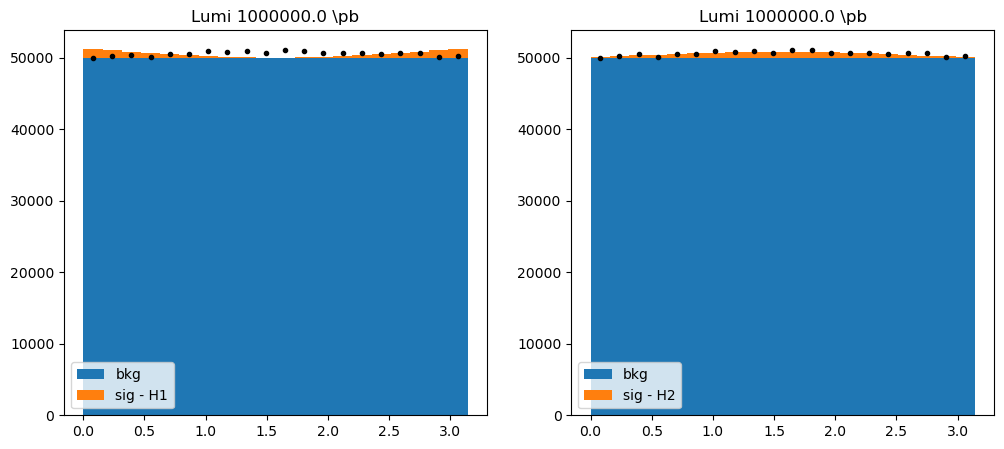

In [7]:
for lumi in lumis:
    Nbins = 20
    
    data = np.load(f"data_lumi_{lumi:.1f}.npy")
    data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))
    
    sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
    sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
    bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
    bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
    
    f = plt.figure(figsize=(12,5))
    plt.subplot(1,2 ,1)
    plt.title(f"Lumi {lumi} \\pb")
    plt.bar(bin_edges[:-1], bkg_counts, width=np.diff(bin_edges), align='edge', label="bkg")
    plt.bar(bin_edges[:-1], sig_counts_h1, bottom=bkg_counts, width=np.diff(bin_edges), align='edge', label="sig - H1" )
    plt.errorbar(bin_centers, data_counts, yerr= np.sqrt(data_counts),marker=".", c="black", linestyle="none",)
    plt.legend()
    
    plt.subplot(1,2 ,2)
    plt.title(f"Lumi {lumi} \\pb")
    plt.bar(bin_edges[:-1], bkg_counts, width=np.diff(bin_edges), align='edge', label="bkg")
    plt.bar(bin_edges[:-1], sig_counts_h2, bottom=bkg_counts, width=np.diff(bin_edges), align='edge', label="sig - H2" )
    plt.errorbar(bin_centers, data_counts, yerr= np.sqrt(data_counts),marker=".", c="black", linestyle="none",)
    plt.legend()

## Binned likelihood

Now we can plot the value of the likelihood for the 3 hypothesis, varying the luminosity of the experiment. 

In [8]:
N_bins = 30
likelihood_H0 = []
likelihood_H1 = []
likelihood_H2 = []

for lumi in lumis:
    data = np.load(f"data_lumi_{lumi:.1f}.npy")
    data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))
    
    sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
    sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
    bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
    bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
    
    nll1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=data_counts)
    nll2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=data_counts)
    params_bkg_only = [0.]
    params_bkg_plus_sig = [1.]
    
    likelihood_H0.append(nll1(params_bkg_only))
    likelihood_H1.append(nll1(params_bkg_plus_sig))
    likelihood_H2.append(nll2(params_bkg_plus_sig))

likelihood_H0 = np.array(likelihood_H0)
likelihood_H1 = np.array(likelihood_H1)
likelihood_H2 = np.array(likelihood_H2)

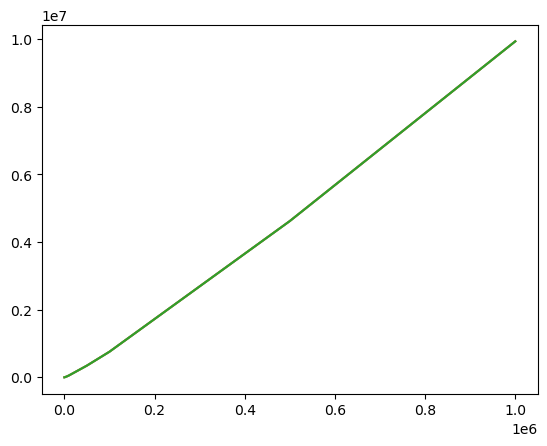

In [9]:
plt.plot(lumis, likelihood_H0, label="Likelihood - H0")
plt.plot(lumis, likelihood_H1, label="Likelihood - H1")
plt.plot(lumis, likelihood_H2, label="Likelihood - H2")
#plt.xscale("log")

Notice that the value of the likelihood alone is not a good discriminant of the difference between the signal and background hypothesis. It is not a good __test statistics__.

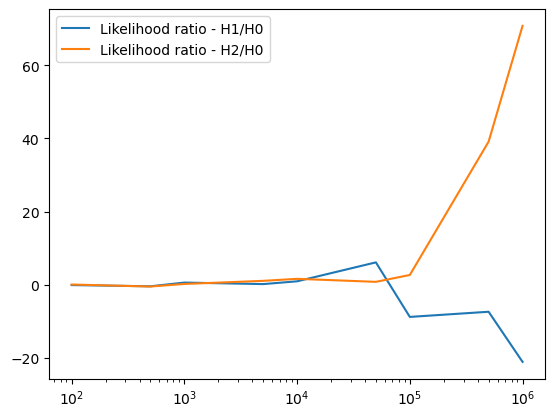

In [11]:
plt.plot(lumis, likelihood_H1 - likelihood_H0, label="Likelihood ratio - H1/H0")
plt.plot(lumis, likelihood_H2 - likelihood_H0, label="Likelihood ratio - H2/H0")
plt.xscale("log")
plt.legend()

If we plot the likelihood ratio between the sig1 (or sig2) and bkg-hypothesis, we notice that there is a slight difference --> we need to investigate more the likelihood ratio distribution under the different hypotheses.

# Likelihood ratio

We use the likelihood ratio as a test statistics. To understand it's power and significance as a test, we need to compute the distribution of the likelihood ratio under the bkg-only and bkg+sig hypothesis. 

To do so, we are going to build "toys": we sample possible experiment outcomes knowing the expected distribution of events in each bin given a certaint hypothesis and luminosity. The toys are then used a _data_ to compute the value of the test statistics. The values are accumulated to analyze the distribution of the likelihood-ratio test under the bkg-only and sig1 or sig2 hypothesis. 

In [12]:
def get_likelihoods(lumi, Nbins):
    data = np.load(f"data_lumi_{lumi:.1f}.npy")
    data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))
    
    sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
    sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
    bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
    bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
    
    nll1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=data_counts)
    nll2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=data_counts)
    return nll1, nll2

In [13]:
lumi = 10000.
Nbins = 20

sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)

nll_h1, nll_h2 = get_likelihoods(lumi, Nbins)

We want to analyze the likelihood ratio under the H0, H1 and H2 hypothesis.

We need toys of the the bkg only distribution and toys including the signal.

In [14]:
N_events_exp_bonly = np.random.poisson(lumi*(bkg_XS))
N_events_sig = np.random.poisson(lumi*(bkg_XS+ sig_XS))

N_events_toys = 100000
params_bkg_only = [0.]
params_bkg_plus_sig = [1.]

# Generat toys using the expected bkg events count
bkg_toys = nll_h1.toss_toys(N_events_toys, params_bkg_only)

# Generat toys using the expected bkg events + sig_h1 counts
sig1_toys = nll_h1.toss_toys(N_events_toys, params_bkg_plus_sig)
# Generat toys using the expected bkg events + sig_h2 counts
sig2_toys = nll_h2.toss_toys(N_events_toys, params_bkg_plus_sig)

The toys are probabilitic samples of the binned PDFs, with a poissonian distribution in each bin.

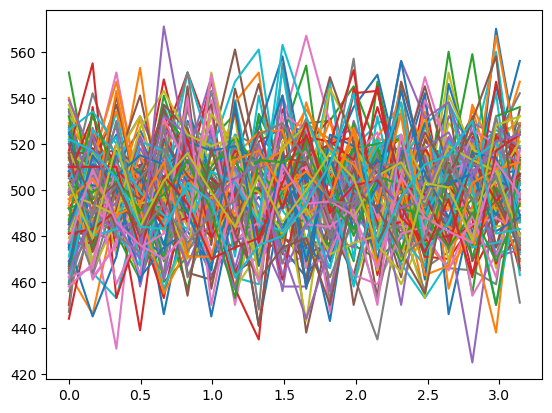

In [15]:
for i in range(100):
    plt.plot(np.linspace(0, np.pi, Nbins), bkg_toys[i])

We have toys, now we can check the distribution of the test statistics, the likelihood ratio:

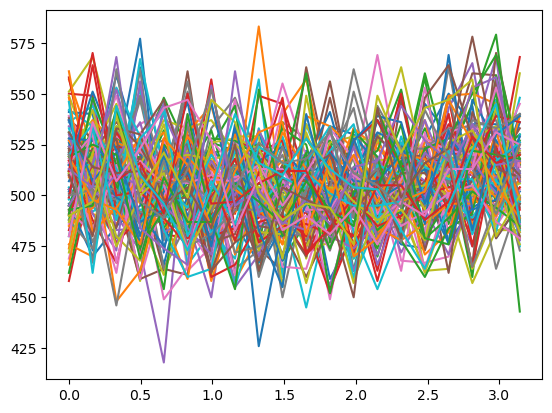

In [16]:
for i in range(100):
    plt.plot(np.linspace(0, np.pi, Nbins), sig1_toys[i])

In [17]:
nll_bkgtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=bkg_toys)
nll_bkgtoys_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=bkg_toys)
nll_sigtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig1_toys)
nll_sigtoys_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=sig2_toys)

# Likelihood ratio of toys generated with the bkg only hypothesis
t_H0_1 = nll_bkgtoys_1(params_bkg_plus_sig) - nll_bkgtoys_1(params_bkg_only) 
t_H0_2 = nll_bkgtoys_2(params_bkg_plus_sig) - nll_bkgtoys_2(params_bkg_only) 
# Likelihood ratio of toys generated with the sig1 +bkg hypothesis
t_H1 = nll_sigtoys_1(params_bkg_plus_sig) - nll_sigtoys_1(params_bkg_only) 
# Likelihood ratio of toys generated with the sig2 +bkg hypothesis
t_H2 = nll_sigtoys_2(params_bkg_plus_sig) - nll_sigtoys_2(params_bkg_only) 

We compute also the "observed" likelihood over __the real data__ for the test statistics for the signal hypothesis 1 and 2.

In [18]:
data = np.load(f"data_lumi_{lumi:.1f}.npy")
data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))

data_nll_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=data_counts)
data_nll_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=data_counts)

obs_t_1 = data_nll_1(params_bkg_plus_sig) - data_nll_1(params_bkg_only)
obs_t_2 = data_nll_2(params_bkg_plus_sig) - data_nll_2(params_bkg_only)

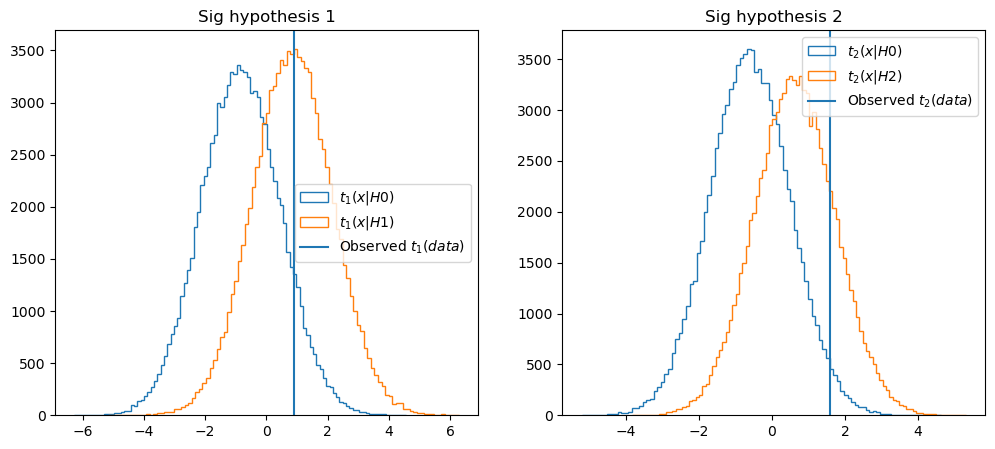

In [19]:
f = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Sig hypothesis 1")
plt.hist(t_H0_1, bins=100, histtype="step", label="$t_1(x|H0)$")
plt.hist(t_H1, bins=100,  histtype="step", label="$t_1(x|H1)$")
plt.axvline(obs_t_1, label="Observed $t_1(data)$")
plt.legend()
plt.subplot(1,2,2)
plt.title("Sig hypothesis 2")
plt.hist(t_H0_2, bins=100, histtype="step", label="$t_2(x|H0)$")
plt.hist(t_H2, bins=100, histtype="step", label="$t_2(x|H2)$")
plt.axvline(obs_t_2, label="Observed $t_2(data)$")
plt.legend()

__Observation__: the test statistics is distributed differently for the bkg-only and bkg+sig hypothesis. The observed data seems to discourage the bkg-only hypothesis, but we need to quantify how much computing the Type I and Type II error given the value of the test significance we want (99% in our case). Given the $t_{cut}$ threshold of the test statistics we can then compare the observed data value to check the outcome of our test.

Now varying the luminosity and number of bins:

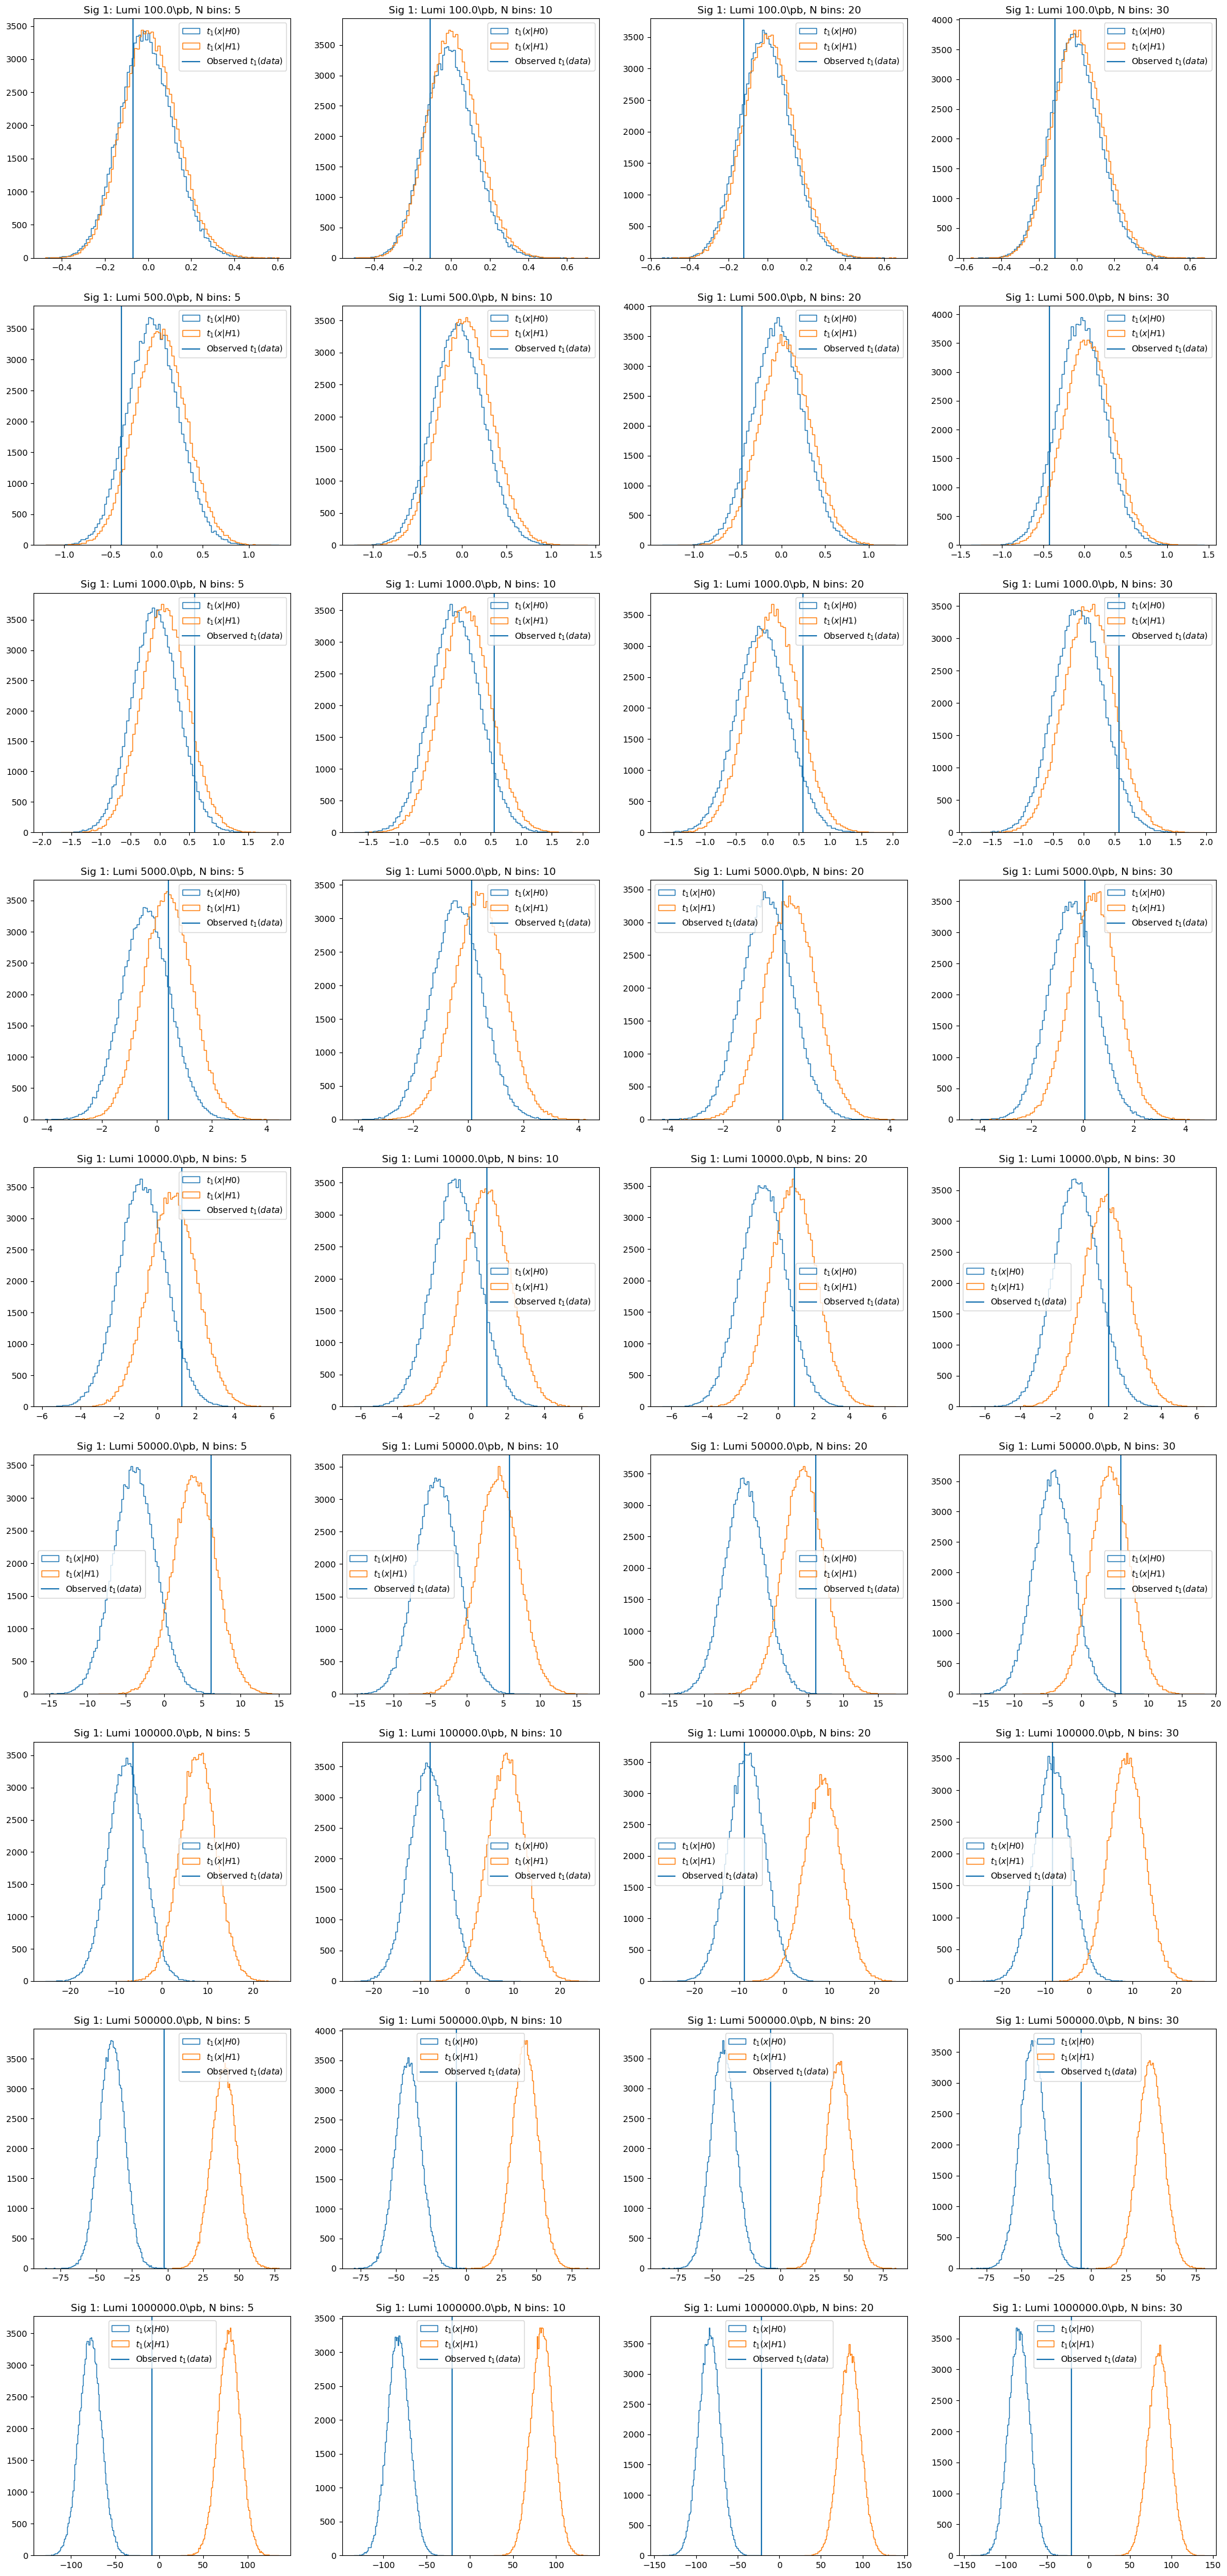

In [20]:
lumi = 1000.
Nbins = 20

f = plt.figure(figsize=(25, 54))
i = 1
for lumi in lumis:
    for Nbins in [5, 10, 20, 30]:
        sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
        sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
        bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
        
        nll_h1, nll_h2 = get_likelihoods(lumi, Nbins)
        
        N_events_exp_bonly = np.random.poisson(lumi*(bkg_XS))
        N_events_sig = np.random.poisson(lumi*(bkg_XS+ sig_XS))
        
        N_events_toys = 100000
        params_bkg_only = [0.]
        params_bkg_plus_sig = [1.]
        
        # Generat toys using the expected bkg events count
        bkg_toys = nll_h1.toss_toys(N_events_toys, params_bkg_only)
        
        # Generat toys using the expected bkg events + sig_h1 counts
        sig1_toys = nll_h1.toss_toys(N_events_toys, params_bkg_plus_sig)
        
        nll_bkgtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=bkg_toys)
        nll_sigtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig1_toys)
        
        # Likelihood ratio of toys generated with the bkg only hypothesis
        t_H0_1 = nll_bkgtoys_1(params_bkg_plus_sig) - nll_bkgtoys_1(params_bkg_only) 
        # Likelihood ratio of toys generated with the sig1 +bkg hypothesis
        t_H1 = nll_sigtoys_1(params_bkg_plus_sig) - nll_sigtoys_1(params_bkg_only) 

        data = np.load(f"data_lumi_{lumi:.1f}.npy")
        data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))
        
        data_nll_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=data_counts)
        
        obs_t_1 = data_nll_1(params_bkg_plus_sig) - data_nll_1(params_bkg_only)

        plt.subplot(9, 4, i)
        plt.title(f"Sig 1: Lumi {lumi}\\pb, N bins: {Nbins}")
        plt.hist(t_H0_1, bins=100, histtype="step", label="$t_1(x|H0)$")
        plt.hist(t_H1, bins=100,  histtype="step", label="$t_1(x|H1)$")
        plt.axvline(obs_t_1, label="Observed $t_1(data)$")
        plt.legend()
        i+=1
        

__N.B.__: increasing the luminosity of the experiment (the number of collected events), the test becomes better and better at discriminating the bkg and sig hypothesis.

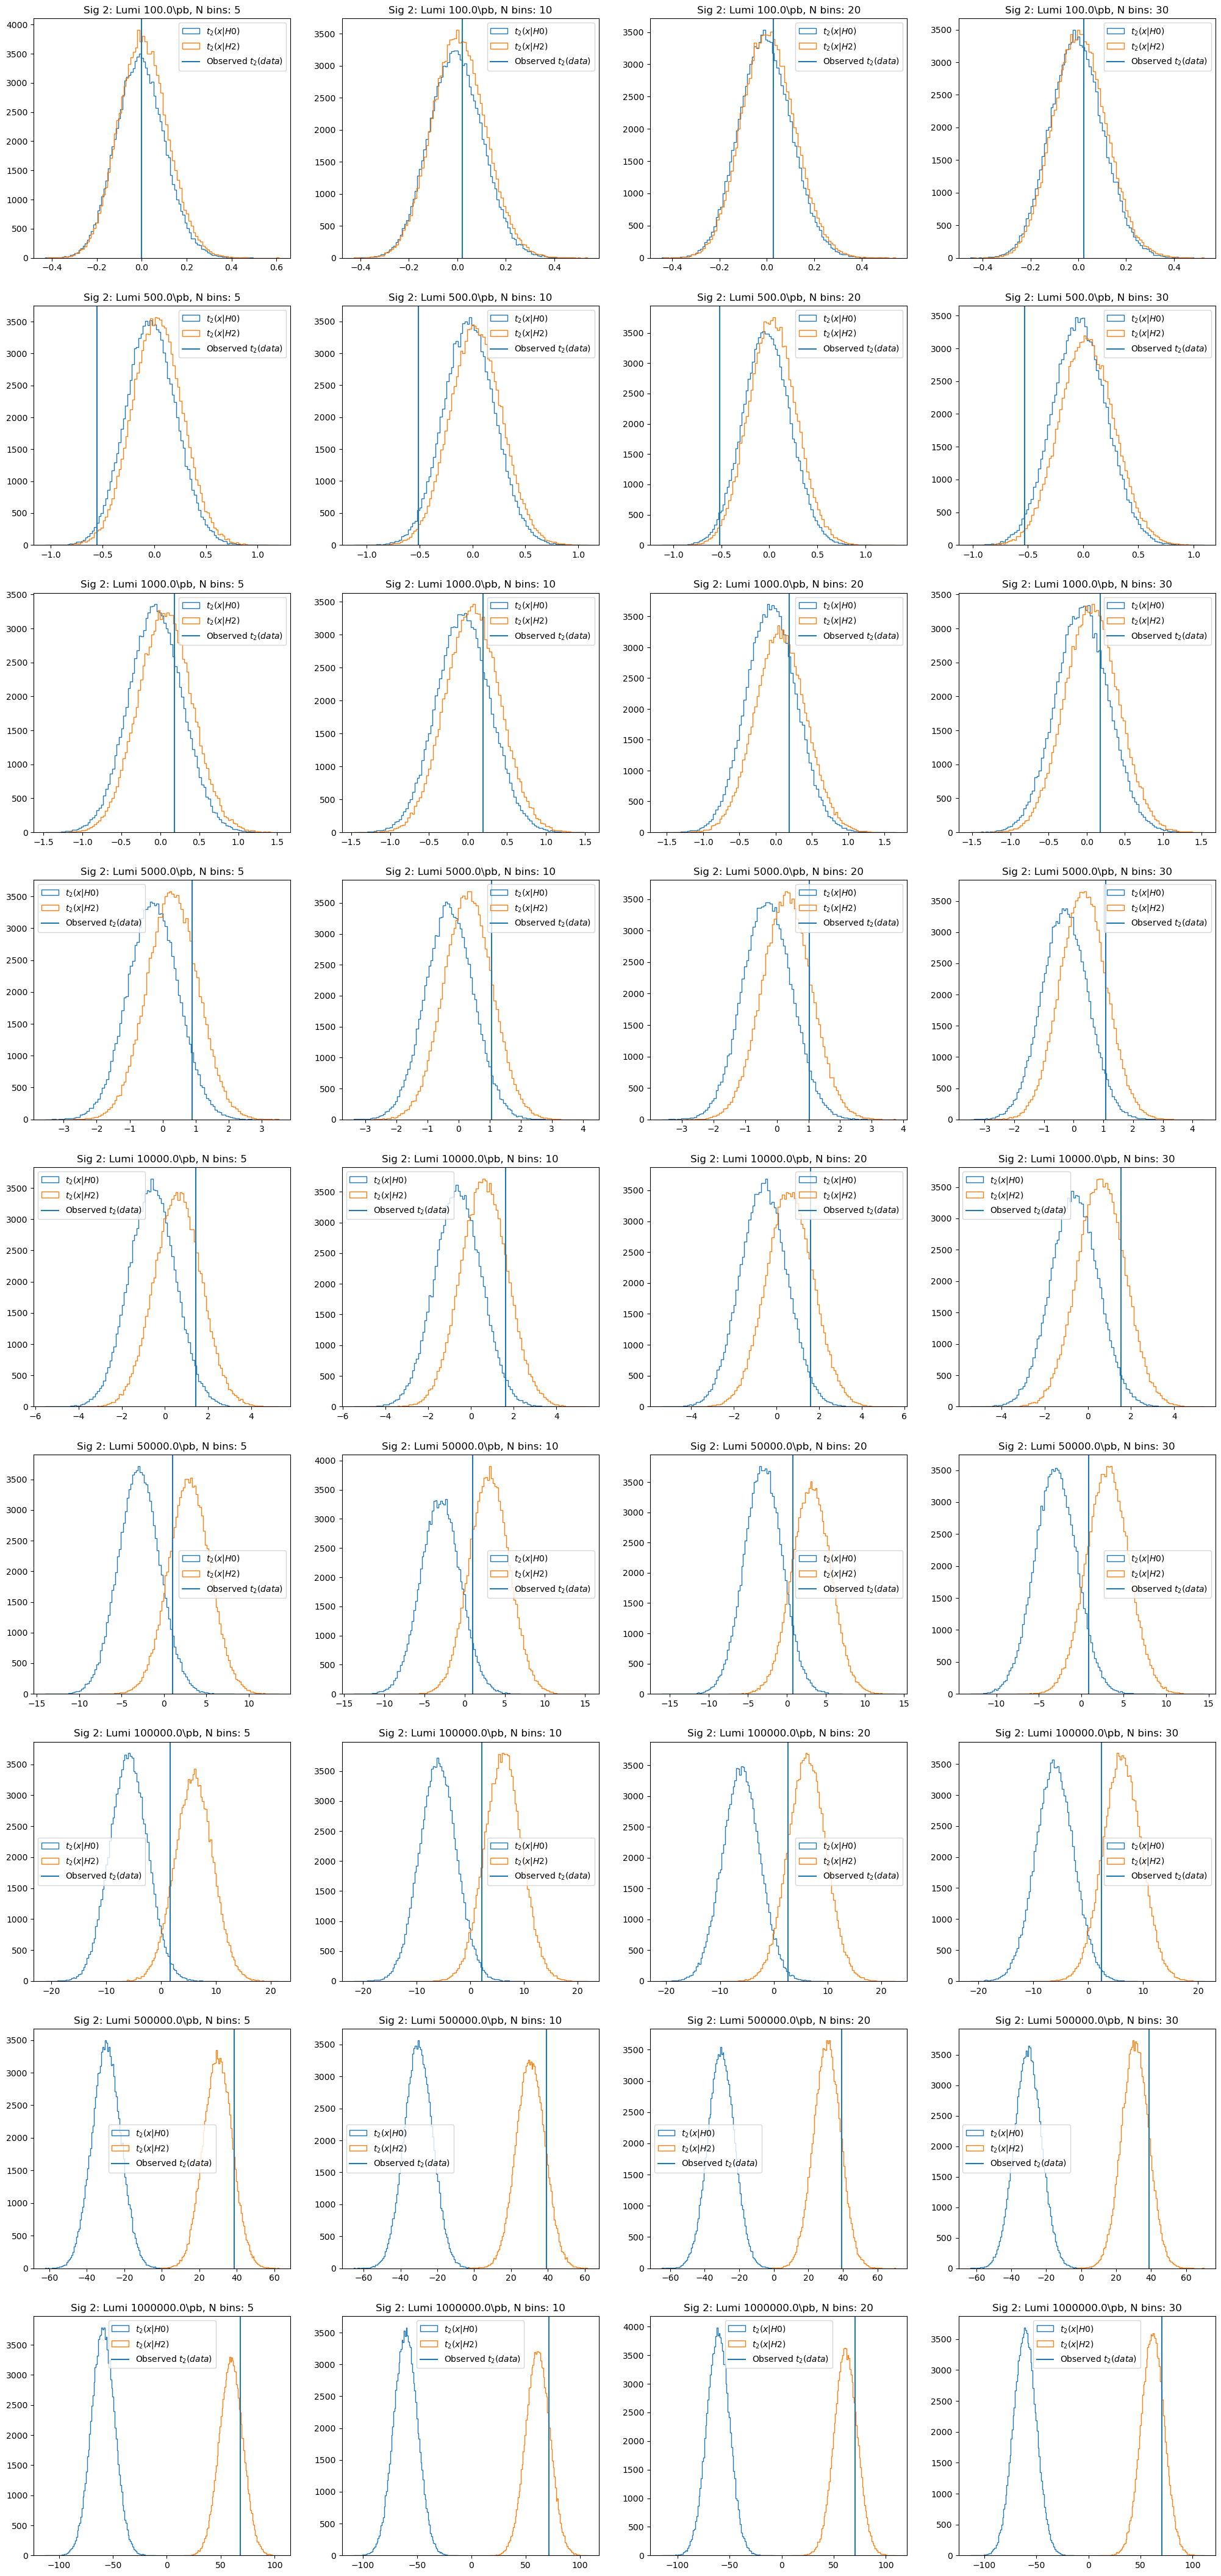

In [33]:
f = plt.figure(figsize=(25, 54))
i = 1
for lumi in lumis:
    for Nbins in [5, 10, 20, 30]:
        sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
        sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
        bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
        
        nll_h1, nll_h2 = get_likelihoods(lumi, Nbins)
        
        N_events_exp_bonly = np.random.poisson(lumi*(bkg_XS))
        N_events_sig = np.random.poisson(lumi*(bkg_XS+ sig_XS))
        
        N_events_toys = 100000
        params_bkg_only = [0.]
        params_bkg_plus_sig = [1.]
        
        # Generat toys using the expected bkg events count
        bkg_toys = nll_h1.toss_toys(N_events_toys, params_bkg_only)
        
        # Generat toys using the expected bkg events + sig_h1 counts
        # Generat toys using the expected bkg events + sig_h2 counts
        sig2_toys = nll_h2.toss_toys(N_events_toys, params_bkg_plus_sig)
        
        nll_bkgtoys_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=bkg_toys)
        nll_sigtoys_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=sig2_toys)
        
        # Likelihood ratio of toys generated with the bkg only hypothesis
        t_H0_2 = nll_bkgtoys_2(params_bkg_plus_sig) - nll_bkgtoys_2(params_bkg_only) 
        # Likelihood ratio of toys generated with the sig1 +bkg hypothesis
        t_H2 = nll_sigtoys_2(params_bkg_plus_sig) - nll_sigtoys_2(params_bkg_only) 

        data = np.load(f"data_lumi_{lumi:.1f}.npy")
        data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))
        
        data_nll_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=data_counts)
        
        obs_t_2 = data_nll_2(params_bkg_plus_sig) - data_nll_2(params_bkg_only)

        plt.subplot(9, 4, i)
        plt.title(f"Sig 2: Lumi {lumi}\\pb, N bins: {Nbins}")
        plt.hist(t_H0_2, bins=100, histtype="step", label="$t_2(x|H0)$")
        plt.hist(t_H2, bins=100,  histtype="step", label="$t_2(x|H2)$")
        plt.axvline(obs_t_2, label="Observed $t_2(data)$")
        plt.legend()
        i+=1

# Significance and Power

We want to find the $t_{cut}$ cutoff to have a 99% test significance. 

We take the distribution of the test statistics under the H0 hypothesis and take the 99% quantile.

In [22]:
Nbins = 30
lumi = 10000.
sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)

nll_h1, nll_h2 = get_likelihoods(lumi, Nbins)
        
N_events_toys = 100000
params_bkg_only = [0.]
params_bkg_plus_sig = [1.]

# Generat toys using the expected bkg events count
bkg_toys = nll_h1.toss_toys(N_events_toys, params_bkg_only)
# Generat toys using the expected bkg events + sig_h1 counts
# Generat toys using the expected bkg events + sig_h2 counts
sig1_toys = nll_h1.toss_toys(N_events_toys, params_bkg_plus_sig)

nll_bkgtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=bkg_toys)
nll_sigtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig1_toys)

# Likelihood ratio of toys generated with the bkg only hypothesis
t_H0_1 = nll_bkgtoys_1(params_bkg_plus_sig) - nll_bkgtoys_1(params_bkg_only) 
# Likelihood ratio of toys generated with the sig1 +bkg hypothesis
t_H1 = nll_sigtoys_1(params_bkg_plus_sig) - nll_sigtoys_1(params_bkg_only) 

# The observed likelihood ratio 
data = np.load(f"data_lumi_{lumi:.1f}.npy")
data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))
data_nll_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=data_counts)
obs_t_1 = data_nll_1(params_bkg_plus_sig) - data_nll_1(params_bkg_only)

The corresponding power of the test is computed as the 
 $$ 1 - \beta = \int_{t_{cut}}^{+\infty} t(x|H1)dx$$

t_cut = 2.1583867402152794, significance= 99%, power = 1.6e+01%


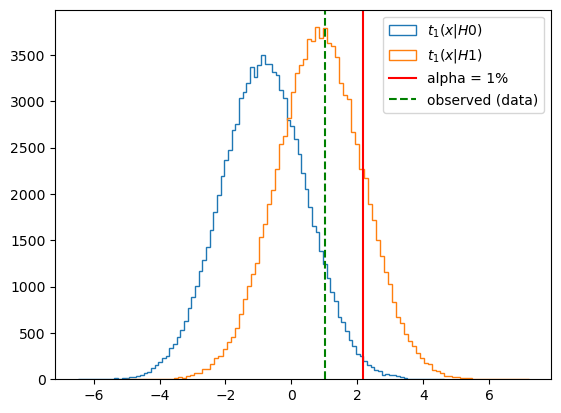

In [24]:
t_cut_1 = np.quantile(t_H0_1, 0.99)
power = 1 - (t_H1 < t_cut_1).sum() / len(t_H1)

print(f"t_cut = {t_cut_1}, significance= 99%, power = {power*100:0.2}%")

plt.hist(t_H0_1, bins=100, histtype="step", label="$t_1(x|H0)$")
plt.hist(t_H1, bins=100,  histtype="step", label="$t_1(x|H1)$")
plt.axvline(t_cut_1, c="red", label="alpha = 1%")
plt.axvline(obs_t_1, c="green", linestyle="dashed", label="observed (data)")
plt.legend()


The value of the test statistics corresponding to a 99% significance level test is 1.00004. The observed value of the test statistics does not invalidate the bkg-only test at 99% significance level. Althought, the power of the test with this luminosity level is only 15%, so this is not a very good test. You can notice that the distribution of the test statistics under the 2 different hypotheses is not well separated.

Now let's vary the luminosity and bins and store the power of the tests

In [36]:
powers_1 = np.zeros((9, 4))
powers_2 = np.zeros((9, 4))

for il, lumi in enumerate(lumis):
    for ib,  Nbins in enumerate([5, 10, 20, 30]):
        sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
        sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
        bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
        
        nll_h1, nll_h2 = get_likelihoods(lumi, Nbins)
        N_events_toys = 100000
        params_bkg_only = [0.]
        params_bkg_plus_sig = [1.]
        
        # Generat toys using the expected bkg events count
        bkg_toys = nll_h1.toss_toys(N_events_toys, params_bkg_only)
        
        # Generat toys using the expected bkg events + sig_h1 counts
        sig1_toys = nll_h1.toss_toys(N_events_toys, params_bkg_plus_sig)
        sig2_toys = nll_h2.toss_toys(N_events_toys, params_bkg_plus_sig)
        
        nll_bkgtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=bkg_toys)
        nll_bkgtoys_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=bkg_toys)
        nll_sigtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig1_toys)
        nll_sigtoys_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=sig2_toys)
        
        # Likelihood ratio of toys generated with the bkg only hypothesis
        t_H0_1 = nll_bkgtoys_1(params_bkg_plus_sig) - nll_bkgtoys_1(params_bkg_only) 
        # Likelihood ratio of toys generated with the sig1 +bkg hypothesis
        t_H1 = nll_sigtoys_1(params_bkg_plus_sig) - nll_sigtoys_1(params_bkg_only) 
        # Likelihood ratio of toys generated with the bkg only hypothesis
        t_H0_2 = nll_bkgtoys_2(params_bkg_plus_sig) - nll_bkgtoys_2(params_bkg_only) 
        # Likelihood ratio of toys generated with the sig1 +bkg hypothesis
        t_H2 = nll_sigtoys_2(params_bkg_plus_sig) - nll_sigtoys_2(params_bkg_only) 
        
        t_cut_1 = np.quantile(t_H0_1, 0.99)
        power_1 = 1 - (t_H1 < t_cut_1).sum() / len(t_H1)
        t_cut_2 = np.quantile(t_H0_2, 0.99)
        power_2 = 1 - (t_H2 < t_cut_2).sum() / len(t_H2)
   
        powers_1[il, ib] = power_1
        powers_2[il, ib] = power_2

Text(0.5, 1.0, 'Sig Hyp 2')

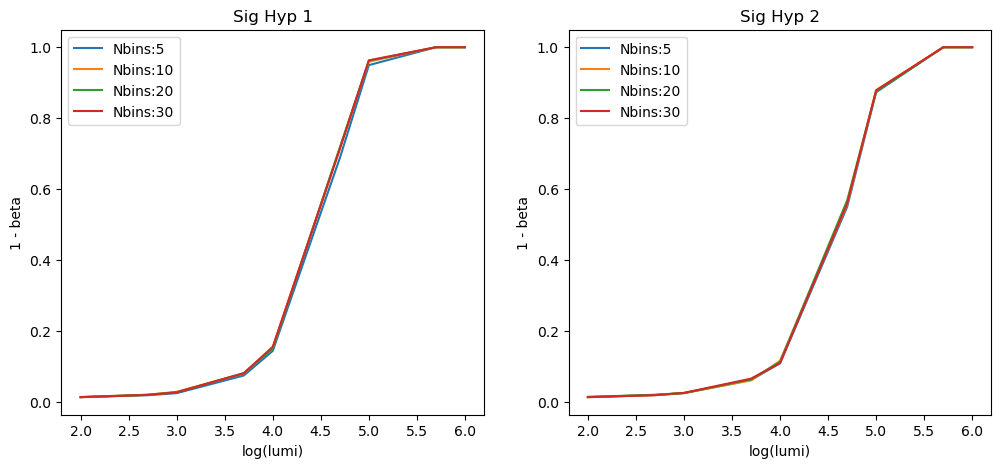

In [37]:
Nbins = [5, 10, 20, 30]
f = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(len(Nbins)):
    plt.plot(np.log10(np.array(lumis)), powers_1[:,i], label=f"Nbins:{Nbins[i]}")
plt.legend()
plt.xlabel("log(lumi)")
plt.ylabel("1 - beta")
plt.title("Sig Hyp 1")

plt.subplot(1,2,2)
for i in range(len(Nbins)):
    plt.plot(np.log10(np.array(lumis)), powers_2[:,i], label=f"Nbins:{Nbins[i]}")
plt.legend()
plt.xlabel("log(lumi)")
plt.ylabel("1 - beta")
plt.title("Sig Hyp 2")

Let's plot again the test statistics distribution for a more powerful test with 1e5 /pb.

t_cut = 1.0000014712718712, significance= 99%, power = 9.6e+01%


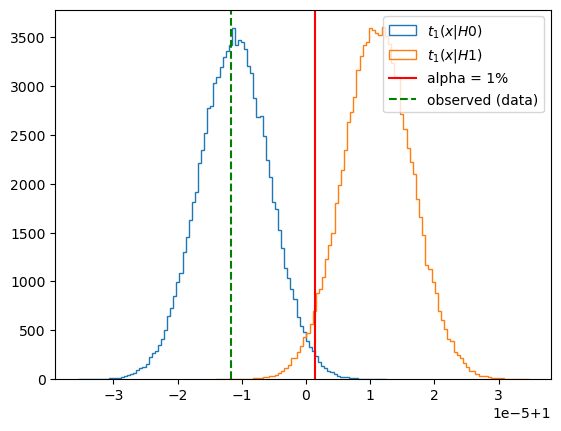

In [38]:
Nbins = 20
lumi = 1e5
sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)

nll_h1, nll_h2 = get_likelihoods(lumi, Nbins)
        
N_events_toys = 100000
params_bkg_only = [0.]
params_bkg_plus_sig = [1.]

# Generat toys using the expected bkg events count
bkg_toys = nll_h1.toss_toys(N_events_toys, params_bkg_only)
# Generat toys using the expected bkg events + sig_h1 counts
# Generat toys using the expected bkg events + sig_h2 counts
sig1_toys = nll_h1.toss_toys(N_events_toys, params_bkg_plus_sig)

nll_bkgtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=bkg_toys)
nll_sigtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig1_toys)

# Likelihood ratio of toys generated with the bkg only hypothesis
t_H0_1 = nll_bkgtoys_1(params_bkg_plus_sig) / nll_bkgtoys_1(params_bkg_only) 
# Likelihood ratio of toys generated with the sig1 +bkg hypothesis
t_H1 = nll_sigtoys_1(params_bkg_plus_sig) / nll_sigtoys_1(params_bkg_only) 

# The observed likelihood ratio 
data = np.load(f"data_lumi_{lumi:.1f}.npy")
data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))
data_nll_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=data_counts)
obs_t_1 = data_nll_1(params_bkg_plus_sig) / data_nll_1(params_bkg_only)

t_cut_1 = np.quantile(t_H0_1, 0.99)
power = 1 - (t_H1 < t_cut_1).sum() / len(t_H1)

print(f"t_cut = {t_cut_1}, significance= 99%, power = {power*100:0.2}%")

plt.hist(t_H0_1, bins=100, histtype="step", label="$t_1(x|H0)$")
plt.hist(t_H1, bins=100,  histtype="step", label="$t_1(x|H1)$")
plt.axvline(t_cut_1, c="red", label="alpha = 1%")
plt.axvline(obs_t_1, c="green", linestyle="dashed", label="observed (data)")
plt.legend()


Also in this case the observed test-statistics does not disprove the bkg only hypothesis. Are we observing a statistical underfluctation (bad luck) or the signal does not exist in data? The only solution is to collect more and more events. 

t_cut = -20.55170103836806, significance= 99%, power = 1e+02%


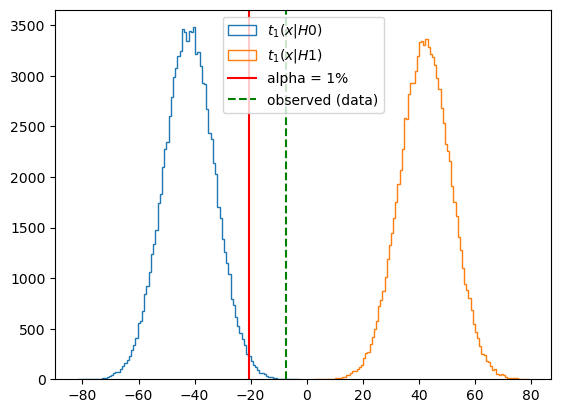

In [39]:
Nbins = 20
lumi = 5e5
sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)

nll_h1, nll_h2 = get_likelihoods(lumi, Nbins)
        
N_events_toys = 100000
params_bkg_only = [0.]
params_bkg_plus_sig = [1.]

# Generat toys using the expected bkg events count
bkg_toys = nll_h1.toss_toys(N_events_toys, params_bkg_only)
# Generat toys using the expected bkg events + sig_h1 counts
# Generat toys using the expected bkg events + sig_h2 counts
sig1_toys = nll_h1.toss_toys(N_events_toys, params_bkg_plus_sig)

nll_bkgtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=bkg_toys)
nll_sigtoys_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig1_toys)

# Likelihood ratio of toys generated with the bkg only hypothesis
t_H0_1 = nll_bkgtoys_1(params_bkg_plus_sig) - nll_bkgtoys_1(params_bkg_only) 
# Likelihood ratio of toys generated with the sig1 +bkg hypothesis
t_H1 = nll_sigtoys_1(params_bkg_plus_sig) - nll_sigtoys_1(params_bkg_only) 

# The observed likelihood ratio 
data = np.load(f"data_lumi_{lumi:.1f}.npy")
data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))
data_nll_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=data_counts)
obs_t_1 = data_nll_1(params_bkg_plus_sig) - data_nll_1(params_bkg_only)

t_cut_1 = np.quantile(t_H0_1, 0.99)
power = 1 - (t_H1 < t_cut_1).sum() / len(t_H1)

print(f"t_cut = {t_cut_1}, significance= 99%, power = {power*100:0.2}%")

plt.hist(t_H0_1, bins=100, histtype="step", label="$t_1(x|H0)$")
plt.hist(t_H1, bins=100,  histtype="step", label="$t_1(x|H1)$")
plt.axvline(t_cut_1, c="red", label="alpha = 1%")
plt.axvline(obs_t_1, c="green", linestyle="dashed", label="observed (data)")
plt.legend()


Using the 5e5/pb dataset (x5 the amount of events of the previous test),  the test becomes very powerful (almost 100%) and data finally disagrees with the bkg only hypothesis. 

# Choose between one of the signal hypothesis

We have falsified the bkg-only hypothesis, but we want to choose between the two different signal hypotheses. We can build another likelihood ratio test using the bkg+sig1 hypothesis as "the bkg" and the bkg+sig2 hypothesis as "the signal". 

In [40]:
Nbins = 30
lumi = 100000.
sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
bins_edges = np.linspace(0, np.pi, Nbins+1)
bin_centers = (bins_edges[1:]+bins_edges[:-1])/2

nll_h1, nll_h2 = get_likelihoods(lumi, Nbins)
        
N_events_toys = 5000000
params_bkg_only = [0.]
params_bkg_plus_sig = [1.]

# Generat toys using the expected bkg events count
sig1_toys = nll_h1.toss_toys(N_events_toys, params_bkg_plus_sig)
sig2_toys = nll_h2.toss_toys(N_events_toys, params_bkg_plus_sig)

nll_sigtoys1_H1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig1_toys)
nll_sigtoys1_H2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=sig1_toys)

nll_sigtoys2_H1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig2_toys)
nll_sigtoys2_H2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=sig2_toys)

# Likelihood ratio of toys generated with the bkg only hypothesis
t_1 = nll_sigtoys1_H2(params_bkg_plus_sig) - nll_sigtoys1_H1(params_bkg_plus_sig)
# Likelihood ratio of toys generated with the sig1 +bkg hypothesis
t_2 = nll_sigtoys2_H2(params_bkg_plus_sig) - nll_sigtoys2_H1(params_bkg_plus_sig)

In [41]:
data = np.load(f"data_lumi_{lumi:.1f}.npy")
data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))

data_nll_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=data_counts)
data_nll_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=data_counts)

obs_t = data_nll_2(params_bkg_plus_sig) - data_nll_1(params_bkg_plus_sig)

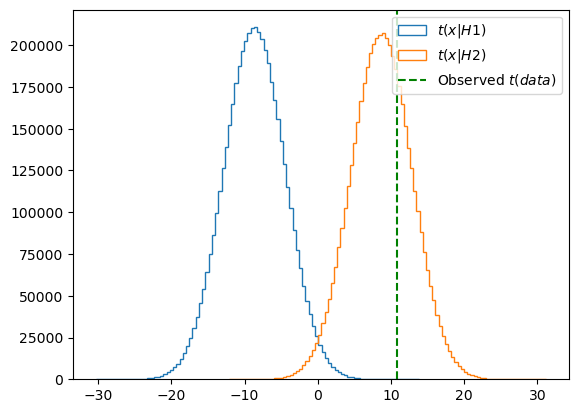

In [42]:
plt.hist(t_1, bins=100, histtype="step", label="$t(x|H1)$")
plt.hist(t_2, bins=100,  histtype="step", label="$t(x|H2)$")
plt.axvline(obs_t, label="Observed $t(data)$", c="green", linestyle="dashed")
plt.legend()

The data prefers the bkg+sig2 hypothesis. 

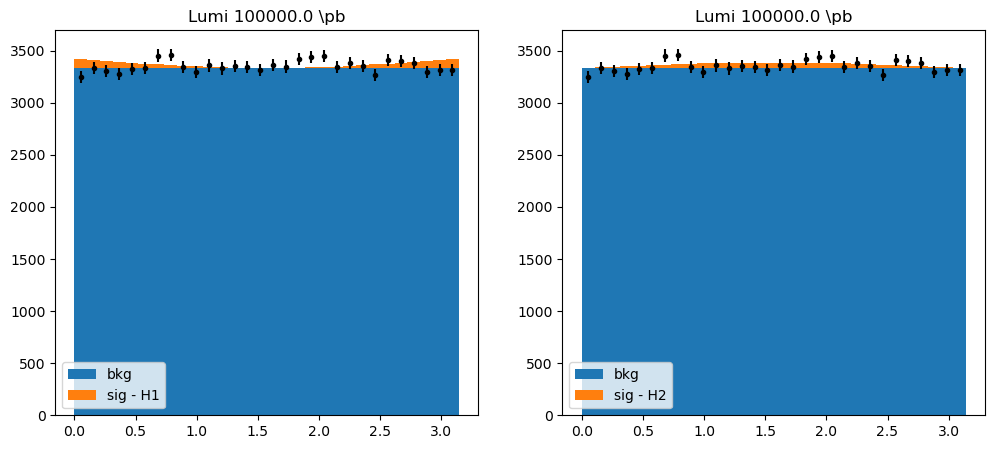

In [43]:
f = plt.figure(figsize=(12,5))
plt.subplot(1,2 ,1)
plt.title(f"Lumi {lumi} \\pb")
plt.bar(bin_edges[:-1], bkg_counts, width=np.diff(bin_edges), align='edge', label="bkg")
plt.bar(bin_edges[:-1], sig_counts_h1, bottom=bkg_counts, width=np.diff(bin_edges), align='edge', label="sig - H1" )
plt.errorbar(bin_centers, data_counts, yerr= np.sqrt(data_counts),marker=".", c="black", linestyle="none",)
plt.legend()

plt.subplot(1,2 ,2)
plt.title(f"Lumi {lumi} \\pb")
plt.bar(bin_edges[:-1], bkg_counts, width=np.diff(bin_edges), align='edge', label="bkg")
plt.bar(bin_edges[:-1], sig_counts_h2, bottom=bkg_counts, width=np.diff(bin_edges), align='edge', label="sig - H2" )
plt.errorbar(bin_centers, data_counts, yerr= np.sqrt(data_counts),marker=".", c="black", linestyle="none",)
plt.legend()

The observed p-value is:

In [44]:
alpha = (t_1 > obs_t).sum() / len(t_1)

from scipy.stats import norm
Nsigmas = norm.ppf(1-alpha)
print(f"Rejected sig H1 with {Nsigmas:.1f} sigmas significance")

Rejected sig H1 with 4.6 sigmas significance


In [57]:
i = 1
results = np.zeros((9, 6))
Nbins_ = [2, 4, 5, 10, 20, 30]
for il, lumi in enumerate(lumis):
    for ib, Nbins in enumerate(Nbins_):
        sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
        sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
        bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
        bins_edges = np.linspace(0, np.pi, Nbins+1)
        bin_centers = (bins_edges[1:]+bins_edges[:-1])/2
        
        nll_h1, nll_h2 = get_likelihoods(lumi, Nbins)
                
        N_events_toys = 1000000
        params_bkg_only = [0.]
        params_bkg_plus_sig = [1.]
        
        # Generat toys using the expected bkg events count
        sig1_toys = nll_h1.toss_toys(N_events_toys, params_bkg_plus_sig)
        sig2_toys = nll_h2.toss_toys(N_events_toys, params_bkg_plus_sig)
        
        nll_sigtoys1_H1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig1_toys)
        nll_sigtoys1_H2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=sig1_toys)
        
        nll_sigtoys2_H1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=sig2_toys)
        nll_sigtoys2_H2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=sig2_toys)
        
        # Likelihood ratio of toys generated with the bkg only hypothesis
        t_1 = nll_sigtoys1_H2(params_bkg_plus_sig) - nll_sigtoys1_H1(params_bkg_plus_sig)

        data = np.load(f"data_lumi_{lumi:.1f}.npy")
        data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))

        data_nll_1 = BinnedNLL(exp_counts_sig=sig_counts_h1, exp_counts_bkg=bkg_counts, data=data_counts)
        data_nll_2 = BinnedNLL(exp_counts_sig=sig_counts_h2, exp_counts_bkg=bkg_counts, data=data_counts)
        
        obs_t = data_nll_2(params_bkg_plus_sig) - data_nll_1(params_bkg_plus_sig)
        # Likelihood ratio of toys generated with the sig1 +bkg hypothesis
        #t_2 = nll_sigtoys2_H2(params_bkg_plus_sig) - nll_sigtoys2_H1(params_bkg_plus_sig)
        
        alpha = (t_1 > obs_t).sum() / len(t_1)
        Nsigmas = norm.ppf(1-alpha)
        results[il, ib] = Nsigmas

Text(0.5, 1.0, 'Sig Hyp 1')

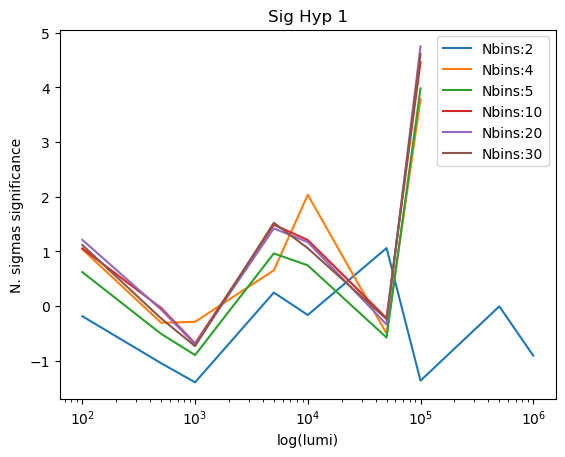

In [58]:
for i in range(len(Nbins_)):
    plt.plot(lumis, results[:,i], label=f"Nbins:{Nbins_[i]}")
plt.legend()
plt.xscale("log")
plt.xlabel("log(lumi)")
plt.ylabel("N. sigmas significance")
plt.title("Sig Hyp 1")


N.B: we get a "inf" N. sigmas for larger luminosity values as many more toys would be needed to estimate the p-values of the test for higher luminosity. This is due to the fact that the observed value is at the very tail of the background-toys distribution. 

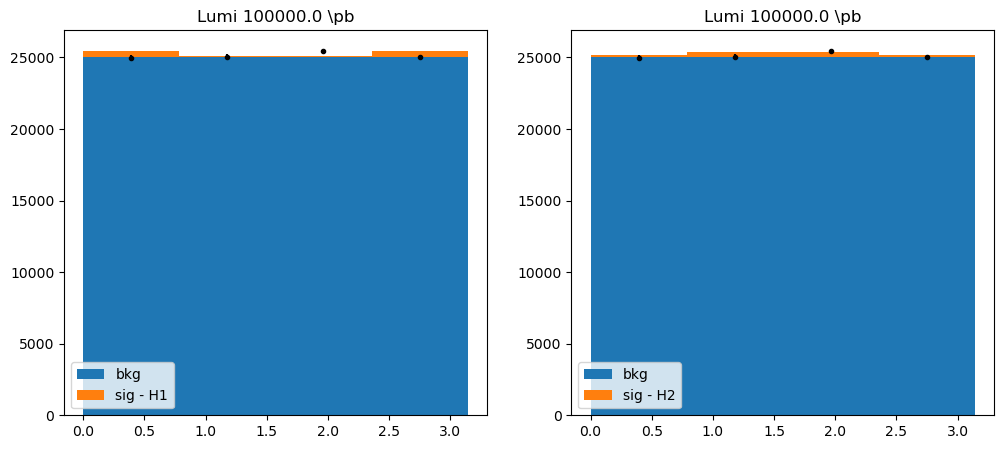

In [59]:
Nbins = 4
lumi = 100000.
sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
bin_edges = np.linspace(0, np.pi, Nbins+1)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
data = np.load(f"data_lumi_{lumi:.1f}.npy")
data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))

f = plt.figure(figsize=(12,5))
plt.subplot(1,2 ,1)
plt.title(f"Lumi {lumi} \\pb")
plt.bar(bin_edges[:-1], bkg_counts, width=np.diff(bin_edges), align='edge', label="bkg")
plt.bar(bin_edges[:-1], sig_counts_h1, bottom=bkg_counts, width=np.diff(bin_edges), align='edge', label="sig - H1" )
plt.errorbar(bin_centers, data_counts, yerr= np.sqrt(data_counts),marker=".", c="black", linestyle="none",)
plt.legend()

plt.subplot(1,2 ,2)
plt.title(f"Lumi {lumi} \\pb")
plt.bar(bin_edges[:-1], bkg_counts, width=np.diff(bin_edges), align='edge', label="bkg")
plt.bar(bin_edges[:-1], sig_counts_h2, bottom=bkg_counts, width=np.diff(bin_edges), align='edge', label="sig - H2" )
plt.errorbar(bin_centers, data_counts, yerr= np.sqrt(data_counts),marker=".", c="black", linestyle="none",)
plt.legend()

# Bonus - alternative test statistics

We can invent an alternative test statistics and test its power agains the likelihood ratio. 
Knowing the shape of the signal we can create 5 bins and compute the ratio between the number of events in the first bin $\theta \in [0.,0.628]$  and in the central bin $\theta \in [1.256,1.884]$. We expect this ratio to be 1 in case the bkg-only hypothesis is true, to be > 1 if the sig1 hypothesis is true and <1 if the sig2 hypothesis is true.

In [60]:
lumi = 5e5
Nbins = 5

data = np.load(f"data_lumi_{lumi:.1f}.npy")
data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))

sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
bin_centers = (bin_edges[1:] + bin_edges[:-1])/2

In [55]:
test_stat_bkg = (bkg_counts[0])/ (bkg_counts[2])
test_stat_sig1 = (sig_counts_h1[0]+ bkg_counts[0])/ (sig_counts_h1[2]+ bkg_counts[2])
test_stat_sig2 = (sig_counts_h2[0]+ bkg_counts[0])/ (sig_counts_h2[2]+ bkg_counts[2])

print(f"Test-statistics bkg-only HP: {test_stat_bkg:.4f}")
print(f"Test-statistics sig1 HP: {test_stat_sig1:.4f}")
print(f"Test-statistics sig2 HP: {test_stat_sig2:.4f}")

Test-statistics bkg-only HP: 1.0000
Test-statistics sig1 HP: 1.0187
Test-statistics sig2 HP: 0.9896


N.B.: This correspondes to the average test statistics as I have used the expected number of events to compute it. It is also called "asimov dataset" estimation. 

Now we throw many "toys" by simulating possible outcomes of the experiment given the expected number of events in the 3rd and 1st bin --> we check the distribution of the test-statistics under different hypothesis as discussed above.

In [56]:
Nsamples = 100000
bkg_samples_0 = np.random.poisson(bkg_counts[0], Nsamples)
bkg_samples_2 = np.random.poisson(bkg_counts[2], Nsamples)
sig1_samples_0 = np.random.poisson(sig_counts_h1[0], Nsamples)
sig1_samples_2 = np.random.poisson(sig_counts_h1[2], Nsamples)
sig2_samples_0 = np.random.poisson(sig_counts_h2[0], Nsamples)
sig2_samples_2 = np.random.poisson(sig_counts_h2[2], Nsamples)

test_stat_bkg = (bkg_samples_0)/ (bkg_samples_2)
test_stat_sig1 = (sig1_samples_0 + bkg_samples_0) /  (sig1_samples_2 + bkg_samples_2)
test_stat_sig2 = (sig2_samples_0 + bkg_samples_0) /  (sig2_samples_2 + bkg_samples_2)

Let's compute also the observed test statistics

In [57]:
test_stat_data = data_counts[0] / data_counts[2]

Now let's compute the test significance and power. Since the test statistics is higher for sig1 then the bkg-only hypotehsis, we can use the same definition of the significance and power as above. Instead the test statistics for sig2 is lower than the bkg-only one, so we need to invert the formulas (by convention the formula assume that the sig-hypothesis gives larger test-stitistics value than the than the bkg one)

In [65]:
t_cut_1 = np.quantile(test_stat_bkg, 0.99)
power_1 = 1 - (test_stat_sig1 < t_cut_1).sum() / len(test_stat_sig1)
print(f"t_cut (sig1) = {t_cut_1}, significance= 99%, power = {power_1*100:0.2}%")

t_cut_2 = np.quantile(test_stat_bkg, 0.01)
power_2 = 1 - (test_stat_sig2 > t_cut_2).sum() / len(test_stat_sig2)

print(f"t_cut (sig2) = {t_cut_2}, significance= 99%, power = {power_2*100:0.2}%")


t_cut (sig1) = 1.010517969238308, significance= 99%, power = 9.7e+01%
t_cut (sig2) = 0.9897380281305057, significance= 99%, power = 5.1e+01%


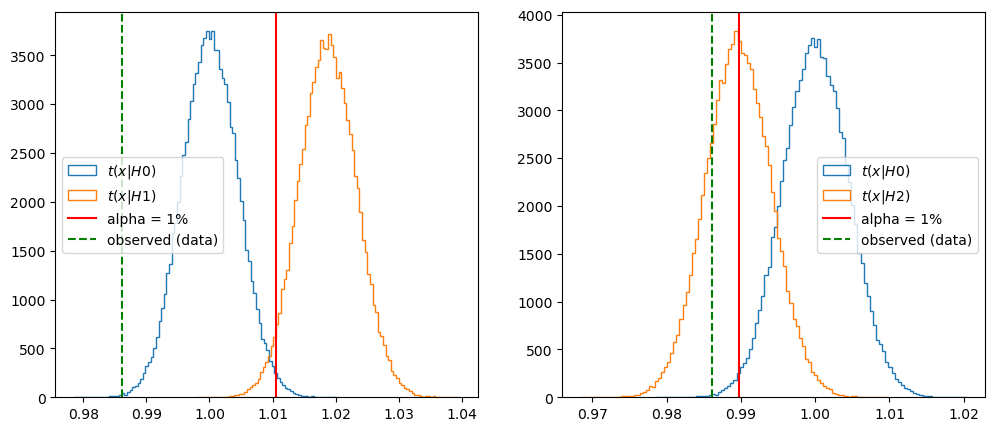

In [64]:
f = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(test_stat_bkg, bins=100, histtype="step", label="$t(x|H0)$")
plt.hist(test_stat_sig1, bins=100,  histtype="step", label="$t(x|H1)$")
plt.axvline(t_cut_1, c="red", label="alpha = 1%")
plt.axvline(test_stat_data, c="green", linestyle="dashed", label="observed (data)")
plt.legend()

plt.subplot(1,2,2)
plt.hist(test_stat_bkg, bins=100, histtype="step", label="$t(x|H0)$")
plt.hist(test_stat_sig2, bins=100,  histtype="step", label="$t(x|H2)$")
plt.axvline(t_cut_2, c="red", label="alpha = 1%")
plt.axvline(test_stat_data, c="green", linestyle="dashed", label="observed (data)")
plt.legend()


Let's compute the power for different luminosities to compare the test performance with the likelihood-ratio one.

In [66]:
powers1 = [ ]
powers2 = [ ]

for lumi in lumis:
    Nbins = 5
    
    data = np.load(f"data_lumi_{lumi:.1f}.npy")
    data_counts, bin_edges = np.histogram(data, bins=Nbins, range=(0, np.pi))
    
    sig_counts_h1 = get_sig_density(lumi, sig_XS, Nbins, 1)
    sig_counts_h2 = get_sig_density(lumi, sig_XS, Nbins, 2)
    bkg_counts = get_bkg_density(lumi, bkg_XS, Nbins)
    bin_centers = (bin_edges[1:] + bin_edges[:-1])/2

    Nsamples = 100000
    bkg_samples_0 = np.random.poisson(bkg_counts[0], Nsamples)
    bkg_samples_2 = np.random.poisson(bkg_counts[2], Nsamples)
    sig1_samples_0 = np.random.poisson(sig_counts_h1[0], Nsamples)
    sig1_samples_2 = np.random.poisson(sig_counts_h1[2], Nsamples)
    sig2_samples_0 = np.random.poisson(sig_counts_h2[0], Nsamples)
    sig2_samples_2 = np.random.poisson(sig_counts_h2[2], Nsamples)
    
    test_stat_bkg = (bkg_samples_0)/ (bkg_samples_2)
    test_stat_sig1 = (sig1_samples_0 + bkg_samples_0) /  (sig1_samples_2 + bkg_samples_2)
    test_stat_sig2 = (sig2_samples_0 + bkg_samples_0) /  (sig2_samples_2 + bkg_samples_2)

    t_cut_1 = np.quantile(test_stat_bkg, 0.99)
    power_1 = 1 - (test_stat_sig1 < t_cut_1).sum() / len(test_stat_sig1)
    print(f"t_cut (sig1) = {t_cut_1}, significance= 99%, power = {power_1*100:0.2}%")
    
    t_cut_2 = np.quantile(test_stat_bkg, 0.01)
    power_2 = 1 - (test_stat_sig2 > t_cut_2).sum() / len(test_stat_sig2)
    
    print(f"t_cut (sig2) = {t_cut_2}, significance= 99%, power = {power_2*100:0.2}%")
    
    powers1.append(power_1)
    powers2.append(power_2)

t_cut (sig1) = 2.2, significance= 99%, power = 1.2%
t_cut (sig2) = 0.45454545454545453, significance= 99%, power = 1.1%
t_cut (sig1) = 1.3932584269662922, significance= 99%, power = 1.4%
t_cut (sig2) = 0.7155172413793104, significance= 99%, power = 1.2%
t_cut (sig1) = 1.2640449438202248, significance= 99%, power = 1.6%
t_cut (sig2) = 0.7922705314009661, significance= 99%, power = 1.3%
t_cut (sig1) = 1.10930753330271, significance= 99%, power = 2.7%
t_cut (sig2) = 0.9007560033809021, significance= 99%, power = 1.8%
t_cut (sig1) = 1.0765199968989543, significance= 99%, power = 4.1%
t_cut (sig2) = 0.9285714285714286, significance= 99%, power = 2.2%
t_cut (sig1) = 1.033668750317977, significance= 99%, power = 1.5e+01%
t_cut (sig2) = 0.9675925880183117, significance= 99%, power = 5.5%
t_cut (sig1) = 1.0235842300008056, significance= 99%, power = 3.1e+01%
t_cut (sig2) = 0.97688908803364, significance= 99%, power = 9.8%
t_cut (sig1) = 1.0104117673702788, significance= 99%, power = 9.7e+01%
t_

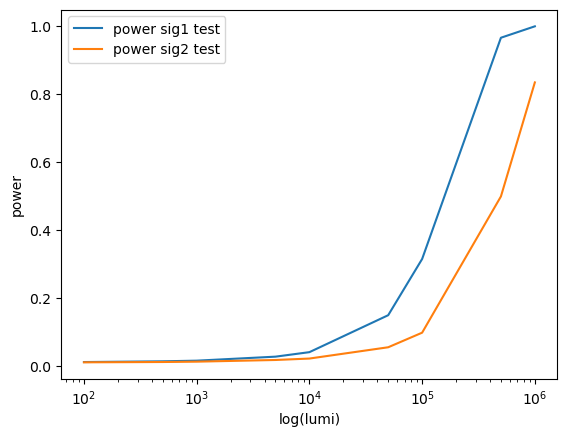

In [116]:
plt.plot(lumis, powers1, label="power sig1 test")
plt.plot(lumis, powers2, label="power sig2 test")
plt.xscale("log")
plt.ylabel("power")
plt.xlabel("log(lumi)")
plt.legend();